In [1]:
# Imports and Spark session
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import BooleanType
import os, json, math
import pandas as pd
import numpy as np

# In cluster use the HDFS path prefix
path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
# path_prefix = "" 

spark = SparkSession.builder.appName("Nutrient Similarity Search").getOrCreate()
print("Spark version:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/15 18:12:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


In [2]:
# Configuration
input_path = f"{path_prefix}/output/nutritional_profiles"
output_dir = f"{path_prefix}/output/SimilaritySearch"

# Select the reference item by name or ID
query_by_name = None   # substring in name/description (case-insensitive). Set None to use ID
query_by_id = 1355368           # alternative: an exact fdc_id/id 2677354

# Global result and constraints
top_k = 20
same_category_only = True        # restrict to the same category (when category exists)
use_per_kcal = True              # use per-kcal densities
scaling = "zscore"              # "none" or "zscore"
show_chart = True
top_n_chart = 10

# Text filters
exclude_allergens = []           # e.g., ['gluten','peanut','milk']
dislikes = []                    # e.g., ['pork','alcohol']

# Strict schema for this dataset: prefer exact names; fall back to detection if missing
strict_schema = True
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'kcal': 'energy',
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'glucose': 'glucose',
    'fructose': 'fructose',
    'sucrose': 'sucrose',
    'lactose': 'lactose',
    'saturated_fat': 'saturated_fat',
    'trans_fat': 'trans_fat',
    'monounsaturated_fat': 'monounsaturated_fat',
    'polyunsaturated_fat': 'polyunsaturated_fat',
    'cholesterol': 'cholesterol',
    'sodium': 'sodium',
    'potassium': 'potassium',
    'calcium': 'calcium',
    'iron': 'iron',
    'magnesium': 'magnesium',
    'phosphorus': 'phosphorus',
    'zinc': 'zinc',
    'copper': 'copper',
    'manganese': 'manganese',
    'selenium': 'selenium',
    'vitamin_a': 'vitamin_a',
    'vitamin_c': 'vitamin_c',
    'vitamin_d': 'vitamin_d',
    'vitamin_e': 'vitamin_e',
    'vitamin_k': 'vitamin_k',
    'thiamin_b1': 'thiamin_b1',
    'riboflavin_b2': 'riboflavin_b2',
    'niacin_b3': 'niacin_b3',
    'vitamin_b6': 'vitamin_b6',
    'folate': 'folate',
    'vitamin_b12': 'vitamin_b12',
    'beta_carotene': 'beta_carotene',
    'lycopene': 'lycopene',
    'lutein_zeaxanthin': 'lutein_zeaxanthin',
    'caffeine': 'caffeine',
    'alcohol': 'alcohol',
    'water': 'water',
    'ash': 'ash',
    'energy': 'energy',
}

# Per-nutrient config: toggle use, set weights, and set relative constraints to the query item
# constraint: None | 'less' | 'more' (compared to the query's value)
feature_config = {
    # Macros
    'protein':              { 'use': True,  'weight': 1.0, 'constraint': None },
    'carb':                 { 'use': True,  'weight': 1.0, 'constraint': None },
    'fat':                  { 'use': True,  'weight': 1.0, 'constraint': None },
    # Carbs detail
    'fiber':                { 'use': True,  'weight': 0.8, 'constraint': None },
    'sugar':                { 'use': True,  'weight': 0.8, 'constraint': None },
    'glucose':              { 'use': False, 'weight': 0.3, 'constraint': None },
    'fructose':             { 'use': False, 'weight': 0.3, 'constraint': None },
    'sucrose':              { 'use': False, 'weight': 0.3, 'constraint': None },
    'lactose':              { 'use': False, 'weight': 0.3, 'constraint': None },
    # Lipids detail
    'saturated_fat':        { 'use': False, 'weight': 0.6, 'constraint': None },
    'trans_fat':            { 'use': False, 'weight': 0.4, 'constraint': None },
    'monounsaturated_fat':  { 'use': False, 'weight': 0.4, 'constraint': None },
    'polyunsaturated_fat':  { 'use': False, 'weight': 0.4, 'constraint': None },
    'cholesterol':          { 'use': False, 'weight': 0.4, 'constraint': None },
    # Sodium & electrolytes
    'sodium':               { 'use': True,  'weight': 0.5, 'constraint': 'less' },
    'potassium':            { 'use': False, 'weight': 0.4, 'constraint': None },
    # Vitamins (enable as needed)
    'vitamin_a':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_c':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_d':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_e':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_k':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'thiamin_b1':           { 'use': False, 'weight': 0.3, 'constraint': None },
    'riboflavin_b2':        { 'use': False, 'weight': 0.3, 'constraint': None },
    'niacin_b3':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_b6':           { 'use': False, 'weight': 0.3, 'constraint': None },
    'folate':               { 'use': False, 'weight': 0.3, 'constraint': None },
    'vitamin_b12':          { 'use': False, 'weight': 0.3, 'constraint': None },
    # Minerals
    'calcium':              { 'use': False, 'weight': 0.4, 'constraint': None },
    'iron':                 { 'use': False, 'weight': 0.4, 'constraint': None },
    'magnesium':            { 'use': False, 'weight': 0.4, 'constraint': None },
    'phosphorus':           { 'use': False, 'weight': 0.4, 'constraint': None },
    'zinc':                 { 'use': False, 'weight': 0.4, 'constraint': None },
    'copper':               { 'use': False, 'weight': 0.3, 'constraint': None },
    'manganese':            { 'use': False, 'weight': 0.3, 'constraint': None },
    'selenium':             { 'use': False, 'weight': 0.3, 'constraint': None },
    # Pigments/others
    'beta_carotene':        { 'use': False, 'weight': 0.2, 'constraint': None },
    'lycopene':             { 'use': False, 'weight': 0.2, 'constraint': None },
    'lutein_zeaxanthin':    { 'use': False, 'weight': 0.2, 'constraint': None },
    # Other components
    'caffeine':             { 'use': False, 'weight': 0.2, 'constraint': None },
    'alcohol':              { 'use': False, 'weight': 0.2, 'constraint': None },
    'water':                { 'use': False, 'weight': 0.2, 'constraint': None },
    'ash':                  { 'use': False, 'weight': 0.2, 'constraint': None },
    # Energy (kcal) — usually disable when use_per_kcal=True because energy/kcal=1
    'energy':               { 'use': False, 'weight': 0.1, 'constraint': None },
}

# Auto-detect extra nutrient columns in the dataset (vitamins/minerals) and add to config with use=False
auto_detect_extra_nutrients = False if strict_schema else True


In [3]:
# Read dataset
path = input_path
print('Input path:', path)
df = spark.read.parquet(path)
df.printSchema()

Input path: hdfs:///projects/BDA-12//output/nutritional_profiles


root
 |-- fdc_id: long (nullable = true)
 |-- food_description: string (nullable = true)
 |-- food_type: string (nullable = true)
 |-- total_nutrients: long (nullable = true)
 |-- energy: double (nullable = true)
 |-- protein: double (nullable = true)
 |-- carbs: double (nullable = true)
 |-- total_fat: double (nullable = true)
 |-- water: double (nullable = true)
 |-- ash: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- caffeine: double (nullable = true)
 |-- fiber: double (nullable = true)
 |-- sugars: double (nullable = true)
 |-- glucose: double (nullable = true)
 |-- fructose: double (nullable = true)
 |-- sucrose: double (nullable = true)
 |-- lactose: double (nullable = true)
 |-- saturated_fat: double (nullable = true)
 |-- monounsaturated_fat: double (nullable = true)
 |-- polyunsaturated_fat: double (nullable = true)
 |-- trans_fat: double (nullable = true)
 |-- cholesterol: double (nullable = true)
 |-- vitamin_a: double (nullable = true)
 |-- vitamin_c:

In [4]:
# Detect columns
def detect_column(df, candidates):
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if col.lower() == cand.lower():
                return df.columns[i]
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if cand.lower() in col.lower():
                return df.columns[i]
    return None

def pick_exact(df, name):
    if not name:
        return None
    # exact match first
    if name in df.columns:
        return name
    # case-insensitive fallback
    for c in df.columns:
        if c.lower() == name.lower():
            return c
    return None

# Prefer strict schema (exact names), fall back to detection if missing
if 'strict_schema' in globals() and strict_schema:
    id_col         = pick_exact(df, schema_columns.get('id')) or detect_column(df, ['fdc_id','id'])
    name_col       = pick_exact(df, schema_columns.get('name')) or detect_column(df, ['food_description','description','food_name','name','brand_name'])
    kcal_col       = pick_exact(df, schema_columns.get('kcal')) or detect_column(df, ['energy_kcal','energy','kcal','calories','1008'])
    category_col   = pick_exact(df, schema_columns.get('category')) or detect_column(df, ['food_type','food_category','wweia_food_category','category'])
    text_col       = detect_column(df, ['ingredients','ingredients_text','description','food_name','name','brand_name'])
    # Macro & common nutrients
    protein_col    = pick_exact(df, schema_columns.get('protein'))    or detect_column(df, ['protein_g','protein','1003'])
    carb_col       = pick_exact(df, schema_columns.get('carb'))       or detect_column(df, ['carbohydrate_g','carbohydrates','carb','carbohydrate','1005','carbs'])
    fat_col        = pick_exact(df, schema_columns.get('fat'))        or detect_column(df, ['fat_g','fat','total_lipid','total_fat','1004'])
    fiber_col      = pick_exact(df, schema_columns.get('fiber'))      or detect_column(df, ['fiber_g','dietary_fiber','fiber','1079'])
    sugar_col      = pick_exact(df, schema_columns.get('sugar'))      or detect_column(df, ['sugar_g','sugar','sugars','2000'])
    sodium_col     = pick_exact(df, schema_columns.get('sodium'))     or detect_column(df, ['sodium_mg','sodium','1093'])
    # Detailed carbs
    glucose_col    = pick_exact(df, schema_columns.get('glucose'))    or detect_column(df, ['glucose'])
    fructose_col   = pick_exact(df, schema_columns.get('fructose'))   or detect_column(df, ['fructose'])
    sucrose_col    = pick_exact(df, schema_columns.get('sucrose'))    or detect_column(df, ['sucrose'])
    lactose_col    = pick_exact(df, schema_columns.get('lactose'))    or detect_column(df, ['lactose'])
    # Lipids detail
    saturated_fat_col       = pick_exact(df, schema_columns.get('saturated_fat'))       or detect_column(df, ['saturated_fat','fa_sat','sfa'])
    trans_fat_col           = pick_exact(df, schema_columns.get('trans_fat'))           or detect_column(df, ['trans_fat','fa_trans'])
    monounsaturated_fat_col = pick_exact(df, schema_columns.get('monounsaturated_fat')) or detect_column(df, ['monounsaturated_fat','fa_mono'])
    polyunsaturated_fat_col = pick_exact(df, schema_columns.get('polyunsaturated_fat')) or detect_column(df, ['polyunsaturated_fat','fa_poly'])
    cholesterol_col         = pick_exact(df, schema_columns.get('cholesterol'))         or detect_column(df, ['cholesterol','cholesterol_mg'])
    # Vitamins
    vitamin_a_col   = pick_exact(df, schema_columns.get('vitamin_a'))   or detect_column(df, ['vitamin_a','vit_a','retinol'])
    vitamin_c_col   = pick_exact(df, schema_columns.get('vitamin_c'))   or detect_column(df, ['vitamin_c','vit_c','ascorbic'])
    vitamin_d_col   = pick_exact(df, schema_columns.get('vitamin_d'))   or detect_column(df, ['vitamin_d','vit_d'])
    vitamin_e_col   = pick_exact(df, schema_columns.get('vitamin_e'))   or detect_column(df, ['vitamin_e','vit_e','tocopherol'])
    vitamin_k_col   = pick_exact(df, schema_columns.get('vitamin_k'))   or detect_column(df, ['vitamin_k','vit_k'])
    thiamin_b1_col  = pick_exact(df, schema_columns.get('thiamin_b1'))  or detect_column(df, ['thiamin_b1','thiamin','vitamin_b1','b1'])
    riboflavin_b2_col = pick_exact(df, schema_columns.get('riboflavin_b2')) or detect_column(df, ['riboflavin_b2','riboflavin','vitamin_b2','b2'])
    niacin_b3_col   = pick_exact(df, schema_columns.get('niacin_b3'))   or detect_column(df, ['niacin_b3','niacin','vitamin_b3','b3'])
    vitamin_b6_col  = pick_exact(df, schema_columns.get('vitamin_b6'))  or detect_column(df, ['vitamin_b6','b6'])
    folate_col      = pick_exact(df, schema_columns.get('folate'))      or detect_column(df, ['folate','folic'])
    vitamin_b12_col = pick_exact(df, schema_columns.get('vitamin_b12')) or detect_column(df, ['vitamin_b12','b12','cobalamin'])
    # Minerals
    calcium_col     = pick_exact(df, schema_columns.get('calcium'))     or detect_column(df, ['calcium_mg','calcium'])
    iron_col        = pick_exact(df, schema_columns.get('iron'))        or detect_column(df, ['iron_mg','iron'])
    magnesium_col   = pick_exact(df, schema_columns.get('magnesium'))   or detect_column(df, ['magnesium_mg','magnesium'])
    phosphorus_col  = pick_exact(df, schema_columns.get('phosphorus'))  or detect_column(df, ['phosphorus_mg','phosphorus'])
    potassium_col   = pick_exact(df, schema_columns.get('potassium'))   or detect_column(df, ['potassium_mg','potassium'])
    zinc_col        = pick_exact(df, schema_columns.get('zinc'))        or detect_column(df, ['zinc_mg','zinc'])
    copper_col      = pick_exact(df, schema_columns.get('copper'))      or detect_column(df, ['copper_mg','copper'])
    manganese_col   = pick_exact(df, schema_columns.get('manganese'))   or detect_column(df, ['manganese_mg','manganese'])
    selenium_col    = pick_exact(df, schema_columns.get('selenium'))    or detect_column(df, ['selenium_mcg','selenium'])
    # Others
    beta_carotene_col     = pick_exact(df, schema_columns.get('beta_carotene'))     or detect_column(df, ['beta_carotene','beta-carotene'])
    lycopene_col          = pick_exact(df, schema_columns.get('lycopene'))          or detect_column(df, ['lycopene'])
    lutein_zeaxanthin_col = pick_exact(df, schema_columns.get('lutein_zeaxanthin')) or detect_column(df, ['lutein_zeaxanthin','lutein','zeaxanthin'])
    caffeine_col          = pick_exact(df, schema_columns.get('caffeine'))          or detect_column(df, ['caffeine'])
    alcohol_col           = pick_exact(df, schema_columns.get('alcohol'))           or detect_column(df, ['alcohol'])
    water_col             = pick_exact(df, schema_columns.get('water'))             or detect_column(df, ['water'])
    ash_col               = pick_exact(df, schema_columns.get('ash'))               or detect_column(df, ['ash'])
else:
    id_col = detect_column(df, ['fdc_id', 'id'])
    name_col = detect_column(df, ['description', 'food_name', 'name', 'brand_name'])
    kcal_col = detect_column(df, ['energy_kcal', 'energy', 'kcal', 'calories', '1008'])
    protein_col = detect_column(df, ['protein_g', 'protein', '1003'])
    carb_col = detect_column(df, ['carbohydrate_g', 'carbohydrates', 'carb', 'carbohydrate', '1005'])
    fat_col = detect_column(df, ['fat_g', 'fat', 'total_lipid', 'total_fat', '1004'])
    fiber_col = detect_column(df, ['fiber_g', 'dietary_fiber', 'fiber', '1079'])
    sugar_col = detect_column(df, ['sugar_g', 'sugar', 'sugars', '2000'])
    sodium_col = detect_column(df, ['sodium_mg', 'sodium', '1093'])
    category_col = detect_column(df, ['food_type', 'food_category', 'wweia_food_category', 'category'])
    text_col = detect_column(df, ['ingredients', 'ingredients_text', 'description', 'food_name', 'name', 'brand_name'])
    # Additional lipids and cholesterol
    saturated_fat_col       = detect_column(df, ['saturated_fat', 'fa_sat', 'sfa'])
    trans_fat_col           = detect_column(df, ['trans_fat', 'fa_trans'])
    monounsaturated_fat_col = detect_column(df, ['monounsaturated_fat', 'fa_mono'])
    polyunsaturated_fat_col = detect_column(df, ['polyunsaturated_fat', 'fa_poly'])
    cholesterol_col         = detect_column(df, ['cholesterol', 'cholesterol_mg'])
    # Vitamins (common)
    vitamin_a_col   = detect_column(df, ['vitamin_a', 'vit_a', 'retinol'])
    vitamin_c_col   = detect_column(df, ['vitamin_c', 'vit_c', 'ascorbic'])
    vitamin_d_col   = detect_column(df, ['vitamin_d', 'vit_d'])
    vitamin_e_col   = detect_column(df, ['vitamin_e', 'vit_e', 'tocopherol'])
    vitamin_k_col   = detect_column(df, ['vitamin_k', 'vit_k'])
    thiamin_b1_col  = detect_column(df, ['thiamin_b1', 'thiamin', 'vitamin_b1', 'b1'])
    riboflavin_b2_col = detect_column(df, ['riboflavin_b2', 'riboflavin', 'vitamin_b2', 'b2'])
    niacin_b3_col   = detect_column(df, ['niacin_b3', 'niacin', 'vitamin_b3', 'b3'])
    vitamin_b6_col  = detect_column(df, ['vitamin_b6', 'b6'])
    folate_col      = detect_column(df, ['folate', 'folic'])
    vitamin_b12_col = detect_column(df, ['vitamin_b12', 'b12', 'cobalamin'])
    # Minerals
    calcium_col    = detect_column(df, ['calcium_mg', 'calcium'])
    iron_col       = detect_column(df, ['iron_mg', 'iron'])
    magnesium_col  = detect_column(df, ['magnesium_mg', 'magnesium'])
    phosphorus_col = detect_column(df, ['phosphorus_mg', 'phosphorus'])
    potassium_col  = detect_column(df, ['potassium_mg', 'potassium'])
    zinc_col       = detect_column(df, ['zinc_mg', 'zinc'])
    copper_col     = detect_column(df, ['copper_mg', 'copper'])
    manganese_col  = detect_column(df, ['manganese_mg', 'manganese'])
    selenium_col   = detect_column(df, ['selenium_mcg', 'selenium'])
    # Others/pigments/compounds
    beta_carotene_col    = detect_column(df, ['beta_carotene', 'beta-carotene'])
    lycopene_col         = detect_column(df, ['lycopene'])
    lutein_zeaxanthin_col= detect_column(df, ['lutein_zeaxanthin', 'lutein', 'zeaxanthin'])
    caffeine_col         = detect_column(df, ['caffeine'])
    alcohol_col          = detect_column(df, ['alcohol'])
    water_col            = detect_column(df, ['water'])
    ash_col              = detect_column(df, ['ash'])

print('Cols:', id_col, name_col, kcal_col)
if not (id_col and name_col and kcal_col):
    raise RuntimeError('Missing essential columns (id/name/kcal).')

# Update feature_config with detected columns
base_feature_cols = {
    'protein': protein_col,
    'carb': carb_col,
    'fat': fat_col,
    'fiber': fiber_col,
    'sugar': sugar_col,
    'glucose': glucose_col,
    'fructose': fructose_col,
    'sucrose': sucrose_col,
    'lactose': lactose_col,
    'sodium': sodium_col,
    'saturated_fat': saturated_fat_col,
    'trans_fat': trans_fat_col,
    'monounsaturated_fat': monounsaturated_fat_col,
    'polyunsaturated_fat': polyunsaturated_fat_col,
    'cholesterol': cholesterol_col,
    'calcium': calcium_col,
    'iron': iron_col,
    'potassium': potassium_col,
    'magnesium': magnesium_col,
    'phosphorus': phosphorus_col,
    'zinc': zinc_col,
    'copper': copper_col,
    'manganese': manganese_col,
    'selenium': selenium_col,
    'vitamin_a': vitamin_a_col,
    'vitamin_c': vitamin_c_col,
    'vitamin_d': vitamin_d_col,
    'vitamin_e': vitamin_e_col,
    'vitamin_k': vitamin_k_col,
    'thiamin_b1': thiamin_b1_col,
    'riboflavin_b2': riboflavin_b2_col,
    'niacin_b3': niacin_b3_col,
    'vitamin_b6': vitamin_b6_col,
    'folate': folate_col,
    'vitamin_b12': vitamin_b12_col,
    'beta_carotene': beta_carotene_col,
    'lycopene': lycopene_col,
    'lutein_zeaxanthin': lutein_zeaxanthin_col,
    'caffeine': caffeine_col,
    'alcohol': alcohol_col,
    'water': water_col,
    'ash': ash_col,
    # Map 'energy' feature to kcal_col
    'energy': kcal_col,
}

for fname, cfg in feature_config.items():
    col_found = base_feature_cols.get(fname)
    feature_config[fname]['column'] = col_found  # may be None if not present in dataset

# Auto-detect extra nutrient columns (vitamins/minerals) not already covered
if auto_detect_extra_nutrients:
    known_cols = set([c for c in base_feature_cols.values() if c])
    keywords = ['vitamin', 'vit_', 'vitamina', 'calcium', 'iron', 'potassium', 'magnesium', 'zinc', 'phosphorus', 'cholesterol']
    for c in df.columns:
        cl = c.lower()
        if c in known_cols:
            continue
        if any(k in cl for k in keywords):
            # add to config if not present
            key = cl.replace(' ', '_')
            if key not in feature_config:
                feature_config[key] = { 'use': False, 'weight': 0.3, 'constraint': None, 'column': c }

print('Feature config (detected columns attached):')
for k,v in feature_config.items():
    print(' ', k, '->', v.get('column'))


Cols: fdc_id food_description energy
Feature config (detected columns attached):
  protein -> protein
  carb -> carbs
  fat -> total_fat
  fiber -> fiber
  sugar -> sugars
  glucose -> glucose
  fructose -> fructose
  sucrose -> sucrose
  lactose -> lactose
  saturated_fat -> saturated_fat
  trans_fat -> trans_fat
  monounsaturated_fat -> monounsaturated_fat
  polyunsaturated_fat -> polyunsaturated_fat
  cholesterol -> cholesterol
  sodium -> sodium
  potassium -> potassium
  vitamin_a -> vitamin_a
  vitamin_c -> vitamin_c
  vitamin_d -> vitamin_d
  vitamin_e -> vitamin_e
  vitamin_k -> vitamin_k
  thiamin_b1 -> thiamin_b1
  riboflavin_b2 -> riboflavin_b2
  niacin_b3 -> niacin_b3
  vitamin_b6 -> vitamin_b6
  folate -> folate
  vitamin_b12 -> vitamin_b12
  calcium -> calcium
  iron -> iron
  magnesium -> magnesium
  phosphorus -> phosphorus
  zinc -> zinc
  copper -> copper
  manganese -> manganese
  selenium -> selenium
  beta_carotene -> beta_carotene
  lycopene -> lycopene
  lutein_z

In [5]:
# Build base dataframe with densities
df_base = df.filter(F.col(kcal_col) > 0)

def safe_div(num_col, den_col):
    return (F.col(num_col) / F.when(F.col(den_col) > 0, F.col(den_col)).otherwise(F.lit(1)))

# Compute per-unit versions for all configured features when possible
if use_per_kcal:
    df_work = df_base
else:
    df_work = df_base

# Map of feature -> selected output column name used downstream
selected_feature_cols = {}

for fname, cfg in feature_config.items():
    src = cfg.get('column')
    if not src:
        # if missing, fill with zero later
        continue
    if use_per_kcal:
        out_col = f"{fname}_per_kcal"
        df_work = df_work.withColumn(out_col, safe_div(src, kcal_col))
    else:
        out_col = f"{fname}_per_100g"
        df_work = df_work.withColumn(out_col, F.col(src))
    selected_feature_cols[fname] = out_col

# Base selection
sel = [id_col, name_col]
if category_col:
    sel.append(category_col)

# Features to use in similarity
feature_keys_used = [k for k, v in feature_config.items() if v.get('use', False)]
feat_cols = [selected_feature_cols.get(k, None) for k in feature_keys_used]
# For missing columns, add a literal 0.0 to keep vector shape consistent
for i, (k, colname) in enumerate(list(zip(feature_keys_used, feat_cols))):
    if colname is None:
        fill_col = f"__missing_{k}"
        df_work = df_work.withColumn(fill_col, F.lit(0.0))
        feat_cols[i] = fill_col

sel.extend([c for c in feat_cols if c])
if text_col and text_col != name_col:
    sel.append(text_col)

pdf = df_work.select(*sel).toPandas()
pdf = pdf.rename(columns={id_col: 'ID', name_col: 'Food'})
if category_col:
    pdf = pdf.rename(columns={category_col: 'Category'})
if text_col and text_col != name_col:
    pdf = pdf.rename(columns={text_col: 'Text'})

# Drop any duplicate columns
try:
    pdf = pdf.loc[:, ~pd.Index(pdf.columns).duplicated()]
except Exception as e:
    print('Duplicate column drop skipped:', e)

print('Rows:', len(pdf))

# Replace NaN with 0 for features
for c in feat_cols:
    pdf[c] = pdf[c].fillna(0.0)

# Build feature matrix and scaling (with weights)
X = pdf[feat_cols].to_numpy(dtype=float)
weights_vec = np.array([feature_config[k].get('weight', 1.0) for k in feature_keys_used], dtype=float)
# Apply scaling
if scaling == 'zscore':
    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0)
    stds = np.where(stds <= 1e-12, 1.0, stds)
    X = (X - means) / stds
else:
    means = np.zeros(X.shape[1]); stds = np.ones(X.shape[1])
# Apply weights
X = X * weights_vec
row_norms = np.linalg.norm(X, axis=1) + 1e-12


Rows: 1784503


In [6]:
# Resolve reference item

def get_food_series(pdf):
    val = pdf['Food']
    if isinstance(val, pd.DataFrame):
        return val.iloc[:, 0]
    return val

def find_query_index(pdf, name_substr, id_val):
    if id_val is not None:
        mask = (pdf['ID'].astype(str) == str(id_val))
        idxs = np.where(mask.values)[0]
        if len(idxs):
            return idxs[0]
    if name_substr is not None:
        s = str(name_substr).lower()
        food_series = get_food_series(pdf)
        mask = food_series.astype(str).str.lower().str.contains(s)
        idxs = np.where(mask.values)[0]
        if len(idxs):
            return idxs[0]
    return None

q_idx = find_query_index(pdf, query_by_name, query_by_id)
if q_idx is None:
    raise ValueError('Reference item not found. Adjust query_by_name or query_by_id.')
q_vec = X[q_idx:q_idx+1, :]  # 1xD
q_norm = float(np.linalg.norm(q_vec) + 1e-12)
q_name = str(get_food_series(pdf).iloc[q_idx])
q_cat = pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None
print('Query:', q_name, '| Category:', q_cat)

Query: CRISPY AND CRUNCHY TAQUITOS | Category: branded_food


In [7]:
# Confirm reference item based on already computed variables
try:
    _ = q_idx
    _ = q_vec
    _ = q_norm
except NameError:
    raise RuntimeError('Variables q_idx/q_vec/q_norm are not set. Run the reference resolution cell.')

# Get name as a scalar even if duplicate columns exist
food_col = pdf['Food']
if isinstance(food_col, pd.DataFrame):
    q_name = str(food_col.iloc[q_idx, 0])
else:
    q_name = str(food_col.iloc[q_idx])
q_cat = pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None
print('Query:', q_name, '| Category:', q_cat)

Query: CRISPY AND CRUNCHY TAQUITOS | Category: branded_food


In [8]:
# Cosine similarity and filtering
sims = (X @ q_vec.T).reshape(-1) / (row_norms * q_norm)
# Exclude the query item itself
sims[q_idx] = -1.0

res_df = pdf.copy()
res_df['Similarity'] = sims

# Map feature columns used for constraints (depending on use_per_kcal)
feat_col_map = {k: selected_feature_cols.get(k) for k in feature_keys_used}

# Query reference values for features
q_vals = {}
for k, col in feat_col_map.items():
    try:
        q_vals[k] = float(res_df.loc[q_idx, col]) if col in res_df.columns else 0.0
    except Exception:
        q_vals[k] = 0.0

mask = res_df['Similarity'] > -1.0

# Per-nutrient constraints according to feature_config
for k in feature_keys_used:
    constraint = feature_config[k].get('constraint')
    col = feat_col_map.get(k)
    if not constraint or not col or col not in res_df.columns:
        continue
    if constraint == 'less':
        mask &= (res_df[col] <= q_vals[k])
    elif constraint == 'more':
        mask &= (res_df[col] >= q_vals[k])

# Category restriction
if same_category_only and ('Category' in res_df.columns) and pd.notna(pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None):
    q_cat = pdf.loc[q_idx, 'Category']
    mask &= (res_df['Category'].astype(str) == str(q_cat))

# Text filters (allergens, dislikes)
if 'Text' in res_df.columns:
    txt = res_df['Text'].astype(str).str.lower()
    if exclude_allergens:
        for k in exclude_allergens:
            kk = str(k).lower()
            mask &= ~txt.str.contains(kk)
    if dislikes:
        for k in dislikes:
            kk = str(k).lower()
            mask &= ~txt.str.contains(kk)

cand = res_df[mask].sort_values('Similarity', ascending=False).head(top_k).copy()

# Percentage differences vs query for selected features
for k in feature_keys_used:
    col = feat_col_map.get(k)
    if col and col in cand.columns:
        qv = q_vals.get(k, 0.0)
        cand[f'Delta {k} (%)'] = ((cand[col] - qv) / (qv + 1e-12)) * 100.0

# Result columns
result_cols = ['ID','Food']
if 'Category' in cand.columns: result_cols.append('Category')
result_cols += ['Similarity']
# include feature values for transparency
for k in feature_keys_used:
    col = feat_col_map.get(k)
    if col and col in cand.columns:
        result_cols.append(col)
# include deltas if present
for k in feature_keys_used:
    dname = f'Delta {k} (%)'
    if dname in cand.columns:
        result_cols.append(dname)

cand = cand[result_cols]
print('Found candidates:', len(cand))

Found candidates: 20


ID,Food,Category,Similarity,protein_per_kcal,carb_per_kcal,fat_per_kcal,fiber_per_kcal,sugar_per_kcal,sodium_per_kcal,Delta protein (%),Delta carb (%),Delta fat (%),Delta fiber (%),Delta sugar (%),Delta sodium (%)
1368952,TAQUITOS IN CORN TORTILLAS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
576117,TAQUITOS IN CORN TORTILLAS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1937866,"CRISPY AND CRUNCHY TAQUITOS, BEEF",branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1946986,"TAQUITOS IN CORN TORTILLAS, BEEF",branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1810080,"TAQUITOS IN CORN TORTILLAS, BEEF",branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
408527,TAQUITOS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
558784,CRISPY AND CRUNCHY TAQUITOS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1509202,TAQUITOS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1661161,TAQUITOS IN CORN TORTILLAS,branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1805353,"CRISPY AND CRUNCHY TAQUITOS, BEEF",branded_food,1.000,0.025035,0.108475,0.050071,0.008511,0.004184,1.418440,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


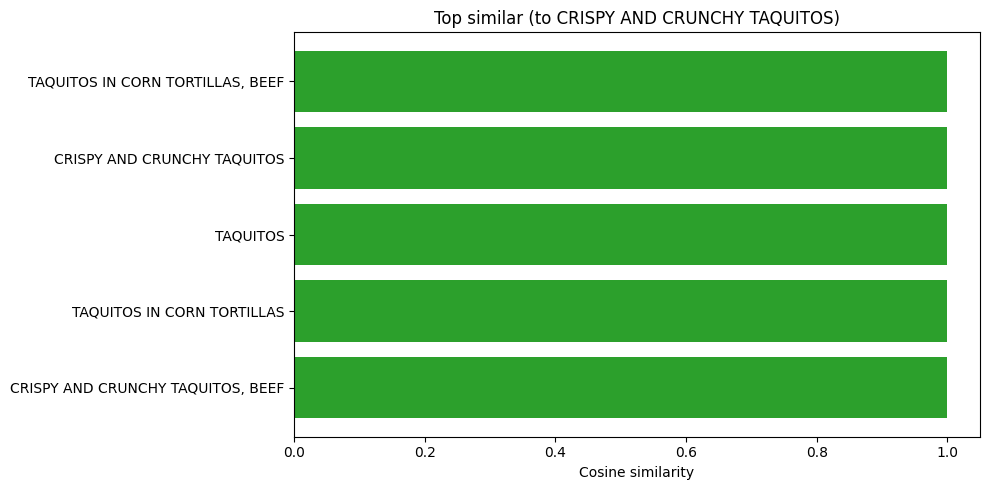

26/01/15 18:13:13 ERROR StandaloneSchedulerBackend: Application has been killed. Reason: Master removed our application: KILLED
26/01/15 18:13:13 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exiting due to error from cluster scheduler: Master removed our application: KILLED
	at org.apache.spark.errors.SparkCoreErrors$.clusterSchedulerError(SparkCoreErrors.scala:291)
	at org.apache.spark.scheduler.TaskSchedulerImpl.error(TaskSchedulerImpl.scala:981)
	at org.apache.spark.scheduler.cluster.StandaloneSchedulerBackend.dead(StandaloneSchedulerBackend.scala:165)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint.markDead(StandaloneAppClient.scala:263)
	at org.apache.spark.deploy.client.StandaloneAppClient$ClientEndpoint$$anonfun$receive$1.applyOrElse(StandaloneAppClient.scala:170)
	at org.apache.spark.rpc.netty.Inbox.$anonfun$process$1(Inbox.scala:115)
	at org.apache.spark.rpc.netty.Inbox.safelyCall(Inbox.scala:213)
	at org.apache.spark.rpc.netty.Inbox.proce

: 

In [ ]:
# Visualization
from IPython.display import display

# Ensure unique columns and clean index for Styler
cand_view = cand.copy()
cand_view = cand_view.loc[:, ~cand_view.columns.duplicated()]
cand_view = cand_view.reset_index(drop=True)
if 'Food' in cand_view.columns:
    cand_view['Food'] = cand_view['Food'].astype(str)

styler = cand_view.style.format({
    'Similarity': '{:.3f}',
    'Delta Protein (%)': '{:.1f}',
    'Delta Sodium (%)': '{:.1f}'
}).set_caption('Nutritional similarity to: ' + str(q_name))
try:
    if hasattr(styler, 'hide_index'):
        styler = styler.hide_index()
    elif hasattr(styler, 'hide'):
        styler = styler.hide(axis='index')
except Exception as e:
    print('Index hide skipped:', e)
styler = styler.background_gradient(cmap='Greens', subset=['Similarity'])
display(styler)

# Chart: Top-N Similarity
try:
    if show_chart and len(cand_view) > 0:
        import matplotlib.pyplot as plt
        topn = cand_view.head(top_n_chart)
        labels = topn['Food'].astype(str).tolist() if 'Food' in topn.columns else [str(i) for i in range(len(topn))]
        values = topn['Similarity'].tolist()
        plt.figure(figsize=(10,5))
        plt.barh(list(reversed(labels)), list(reversed(values)), color='#2ca02c')
        plt.xlabel('Cosine similarity')
        plt.title('Top similar (to ' + str(q_name) + ')')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Chart skipped:', e)